In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import make_blobs
X,y=make_blobs(n_samples=10000,centers=3,n_features=2,random_state=42)

USL>> we will not be using y

In [3]:
X

array([[-2.9688544 ,  7.93444368],
       [ 3.16120524, -0.25650696],
       [-1.89542677,  9.38974199],
       ...,
       [ 4.18013744,  1.63408139],
       [-2.20139585,  7.30411774],
       [-4.31294811,  9.34575702]], shape=(10000, 2))

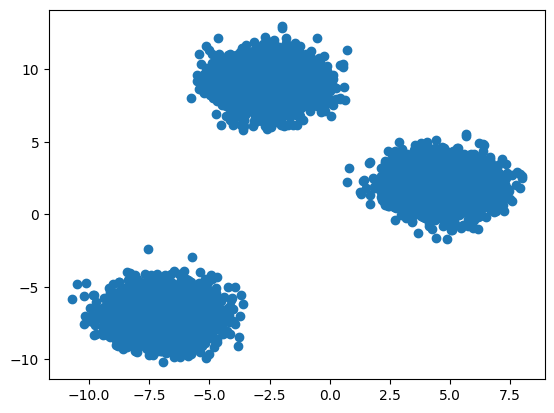

In [4]:
plt.scatter(X[:,0],X[:,1])

In [5]:
#plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [7]:
X_train.shape

(7000, 2)

In [8]:
y_train.shape

(7000,)

In [9]:
from sklearn.cluster import KMeans
k_means=KMeans(n_clusters=3,init='k-means++')
k_means.fit(X_train) #fit_predict also used

KMeans(n_clusters=3)

In [10]:
y_label=k_means.predict(X_train)

In [11]:
y_label

array([0, 1, 1, ..., 1, 2, 1], shape=(7000,), dtype=int32)

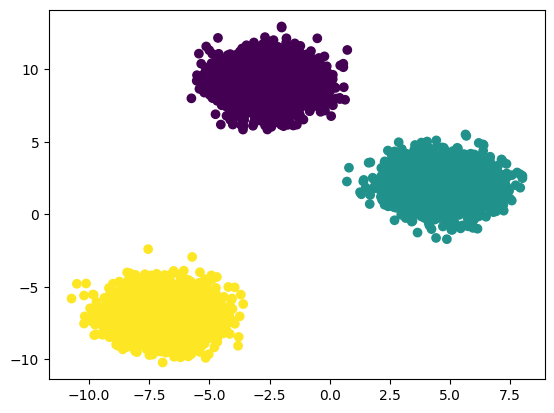

In [12]:
plt.scatter(X[:,0],X[:,1],c=y) # y is actual y # complete data

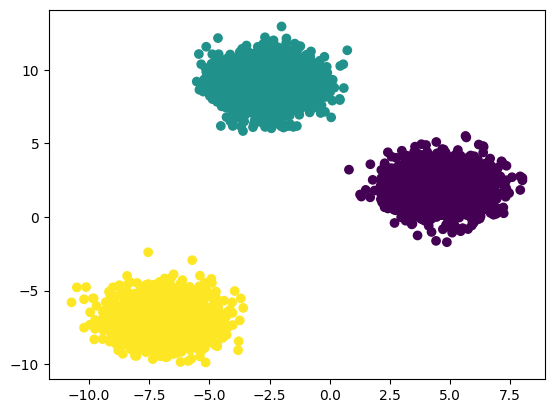

In [13]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_label) # on train data

How better this clustering model is?


In [14]:
from sklearn.metrics import silhouette_score

In [15]:
silhouette_score(X_train,k_means.labels_) # close to 1 so this is a good model

np.float64(0.8411999578909737)

how to select k(centroid)>> elbow method

In [16]:
k_means.inertia_ # for k =3 is the wcss distance

14084.749490309252

In [17]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [18]:
wcss  #wcss is decressing

[466441.8527756252,
 132849.93331676023,
 14084.749490309252,
 12629.691519801328,
 11047.216535878237,
 9989.17459122124,
 9090.823822892931,
 7512.039945164766,
 6990.923810014914,
 6065.810056900139]

Text(0, 0.5, 'wcss')

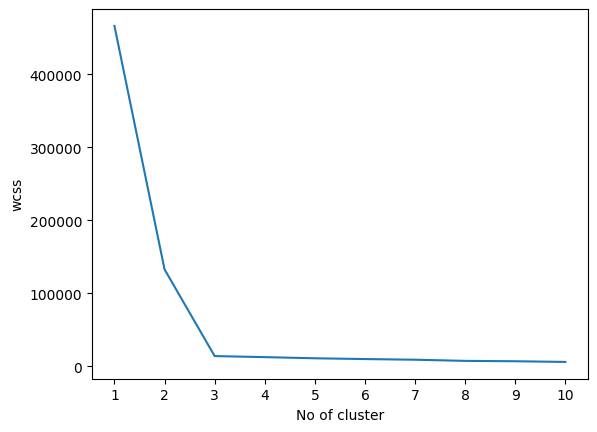

In [27]:
#plot

plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("No of cluster")
plt.ylabel("wcss")

based on the plot above the optimal no of clustering should be 3

In [20]:
!pip install kneed

You should consider upgrading via the 'C:\Users\tanmo\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [21]:
from kneed import KneeLocator

In [22]:
k1=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
k1.elbow

np.int64(3)

In [23]:
silhouette_coeff=[]

for k in range(2,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(X_train)
    score=silhouette_score(X_train,kmeans.labels_)
    silhouette_coeff.append(score)

In [24]:
silhouette_coeff

[np.float64(0.7032725662410718),
 np.float64(0.8411999578909737),
 np.float64(0.6539589417290995),
 np.float64(0.46900763925409633),
 np.float64(0.3029020318553096),
 np.float64(0.316100943139258),
 np.float64(0.31919645066039476),
 np.float64(0.3183605357958252),
 np.float64(0.3233509624604774)]

Text(0, 0.5, 'silhouette_coefficient')

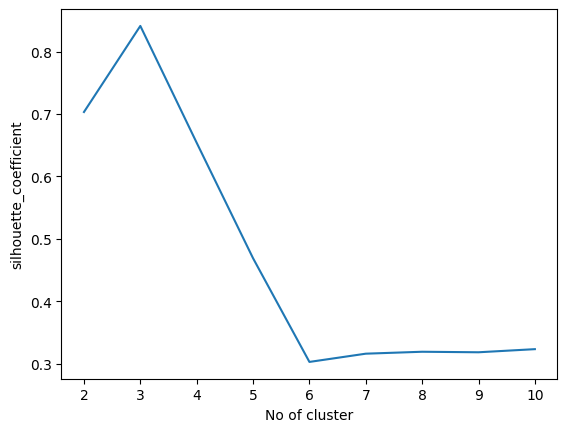

In [25]:
plt.plot(range(2,11),silhouette_coeff)
plt.xticks(range(2,11))
plt.xlabel("No of cluster")
plt.ylabel("silhouette_coefficient")